<a href="https://colab.research.google.com/github/Gmusebe/Audio_Analysis/blob/main/Audio_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install pathlib tqdm numpy resemblyzer

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 15.7 MB 698 kB/s 
     |████████████████████████████████| 66 kB 3.2 MB/s 
     |████████████████████████████████| 78 kB 7.6 MB/s 
  Created wheel for webrtcvad: filename=webrtcvad-2.0.10-cp37-cp37m-linux_x86_64.whl size=72442 sha256=07dec586f5a275a24d5a373a699456eb52211e9acaaab3739b46328f964d3597
  Stored in directory: /root/.cache/pip/wheels/11/f9/67/a3158d131f57e1c0a7d8d966a707d4a2fb27567a4fe47723ad
  Created wheel for typing: filename=typing-3.7.4.3-py3-none-any.whl size=26325 sha256=f863ca1eca2af9e79d6679734273cc08514e899421f070e83981edcc0e5f2143
  Stored in directory: /root/.cache/pip/wheels/35/f3/15/01aa6571f0a72ee6ae7b827c1491c37a1f72d686fd22b43b0e
Successfully built webrtcvad typing


In [3]:
from resemblyzer import preprocess_wav, VoiceEncoder
from google.colab import drive
import matplotlib.pyplot as plt
from pathlib import Path
from glob2 import glob
from tqdm import tqdm
import numpy as np

In [4]:
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
wav_fpaths = list(
    glob("drive/MyDrive/audio-recognition/audio/Voices/*/*.mp3"))
wavs = [preprocess_wav(wav_fpath) for wav_fpath in \
        tqdm(wav_fpaths, "Preprocessing wavs", len(wav_fpaths), unit=" utterances")]

Preprocessing wavs:   0%|          | 0/12 [00:00<?, ? utterances/s]/usr/local/lib/python3.7/dist-packages/librosa/core/audio.py:165: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
Preprocessing wavs:   8%|▊         | 1/12 [00:02<00:32,  2.99s/ utterances]/usr/local/lib/python3.7/dist-packages/librosa/core/audio.py:165: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
Preprocessing wavs:  17%|█▋        | 2/12 [00:04<00:21,  2.17s/ utterances]/usr/local/lib/python3.7/dist-packages/librosa/core/audio.py:165: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.warn("PySoundFile failed. Trying audioread instead.")
Preprocessing wavs:  25%|██▌       | 3/12 [00:06<00:16,  1.83s/ utterances]/usr/local/lib/python3.7/dist-packages/librosa/core/audio.py:165: UserWarning: PySoundFile failed. Trying audioread instead.
  warnings.wa

In [7]:
embeds

array([[0.0000000e+00, 9.3821669e-04, 2.5655876e-03, ..., 2.0242283e-02,
        1.3402395e-02, 1.9720210e-05],
       [0.0000000e+00, 2.1767663e-03, 1.7956056e-02, ..., 5.6758840e-02,
        3.1480316e-02, 6.0546404e-04],
       [0.0000000e+00, 2.1767663e-03, 1.7956056e-02, ..., 5.6758840e-02,
        3.1480316e-02, 6.0546404e-04],
       ...,
       [0.0000000e+00, 2.3588032e-02, 5.8509346e-02, ..., 0.0000000e+00,
        3.8118336e-02, 1.7195433e-02],
       [0.0000000e+00, 4.4384260e-02, 5.9784777e-03, ..., 0.0000000e+00,
        1.1205573e-02, 7.2293770e-03],
       [3.1346914e-03, 1.9785792e-02, 2.5495142e-02, ..., 0.0000000e+00,
        9.3865590e-03, 2.0712305e-02]], dtype=float32)

In [6]:
encoder = VoiceEncoder()
embeds = np.array([encoder.embed_utterance(wav) for wav in wavs])
speakers = np.array([Path(fpath).parent.name for fpath in wav_fpaths])
names = np.array([Path(fpath).stem for fpath in wav_fpaths])

Loaded the voice encoder model on cpu in 0.01 seconds.


In [8]:
print(speakers)
names

['real' 'real' 'real' 'real' 'real' 'real' 'fake' 'fake' 'fake' 'fake'
 'fake' 'fake']


array(['ruto1', 'ruto3', 'ruto2', 'ruto4', 'ruto5', 'ruto6', 'ruto1',
       'ruto2', 'ruto3', 'ruto4', 'ruto5', 'ruto6'], dtype='<U5')

In [9]:
gt_indices = np.random.choice(*np.where(speakers == "real"), 3, replace=False) 
mask = np.zeros(len(embeds), dtype=np.bool)
mask[gt_indices] = True
gt_embeds = embeds[mask]
gt_names = names[mask]
gt_speakers = speakers[mask]
embeds, speakers, names = embeds[~mask], speakers[~mask], names[~mask]

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  


In [10]:
scores = (gt_embeds @ embeds.T).mean(axis=0)

In [11]:
sort = np.argsort(scores)[::-1]
scores, names, speakers = scores[sort], names[sort], speakers[sort]

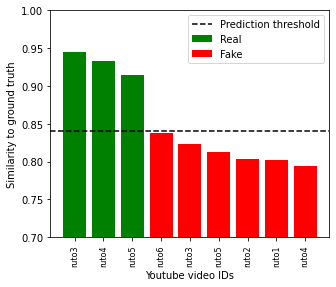

In [13]:
fig, _ = plt.subplots(figsize=(5, 5))
indices = np.arange(len(scores))
plt.axhline(0.84, ls="dashed", label="Prediction threshold", c="black")
plt.bar(indices[speakers == "real"], scores[speakers == "real"], color="green", label="Real")
plt.bar(indices[speakers == "fake"], scores[speakers == "fake"], color="red", label="Fake")
plt.legend()
plt.xticks(indices, names, rotation="vertical", fontsize=8)
plt.xlabel("Youtube video IDs")
plt.ylim(0.7, 1)
plt.ylabel("Similarity to ground truth")
fig.subplots_adjust(bottom=0.25)
plt.show()